# 01 · Cleaning, cohorts and segments

**Stakeholder:** the marketing team of an online gift retailer.
**Business question:** *Which customers should we retain, upsell or win back, and what is each worth over the next 6 months?*
**Success KPIs:** (1) rank customers by future value (share of next-6-month revenue found in the top 10%);
(2) flag customers who will not buy again (ROC-AUC vs a simple recency rule); (3) segments a marketer can act on.

**Data:** UCI *Online Retail II* (CC BY 4.0) - every invoice line of a UK online retailer, 2009-12-01 to 2011-12-09.

In [1]:
import json, warnings
warnings.filterwarnings("ignore")
import pandas as pd, numpy as np
from IPython.display import Image
from custintel import config as C, ingest
raw = ingest.load_raw()
print(raw.shape)
raw.head(3)

(1067371, 8)


,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom


In [2]:
print("missing values %:")
print((raw.isna().mean() * 100).round(1).to_string())
print("\ncancellation invoices:", raw.invoice.str.startswith("C").sum(), "| negative/zero price:", (raw.price <= 0).sum(),
      "| exact duplicate lines:", raw.duplicated().sum())
raw.quantity.describe().round(1).to_frame("quantity").T

missing values %:
invoice          0.0
stock_code       0.0
description      0.4
quantity         0.0
invoice_date     0.0
price            0.0
customer_id     22.8
country          0.0



cancellation invoices: 19494 | negative/zero price: 6207 | exact duplicate lines: 34335


,count,mean,std,min,25%,50%,75%,max
quantity,1067371.0,9.9,172.7,-80995.0,1.0,3.0,10.0,80995.0


**What the raw data hides:** 22.8% of lines have no Customer ID (guest checkouts), ~2% are cancellations, and there are
duplicates, postage/fee rows, bad-debt adjustments and zero-price lines. Ignoring them would inflate revenue and corrupt every
customer-level metric, so each rule is applied in `custintel.clean` and counted:

In [3]:
rep = json.loads((C.ARTIFACTS_DIR / "cleaning_report.json").read_text())
pd.DataFrame(rep["steps"])

,step,rows_removed,rows_left
0,exact duplicate lines,34335,1033036
1,bad-debt adjustment invoices (A...),6,1033030
2,"non-product stock codes (postage, fees, manual...",5436,1027594
3,price <= 0,5988,1021606
4,cancellation invoices (C...) moved to the retu...,17922,1003684
5,quantity <= 0 on non-cancellation lines (write...,0,1003684
6,lines without a Customer ID (kept for revenue ...,226857,776827


guest lines: 226,857 = 13.1% of revenue (kept for totals, unusable per customer)
clean: 776,827 lines | 36,600 invoices | 5,853 customers | £17,081,129


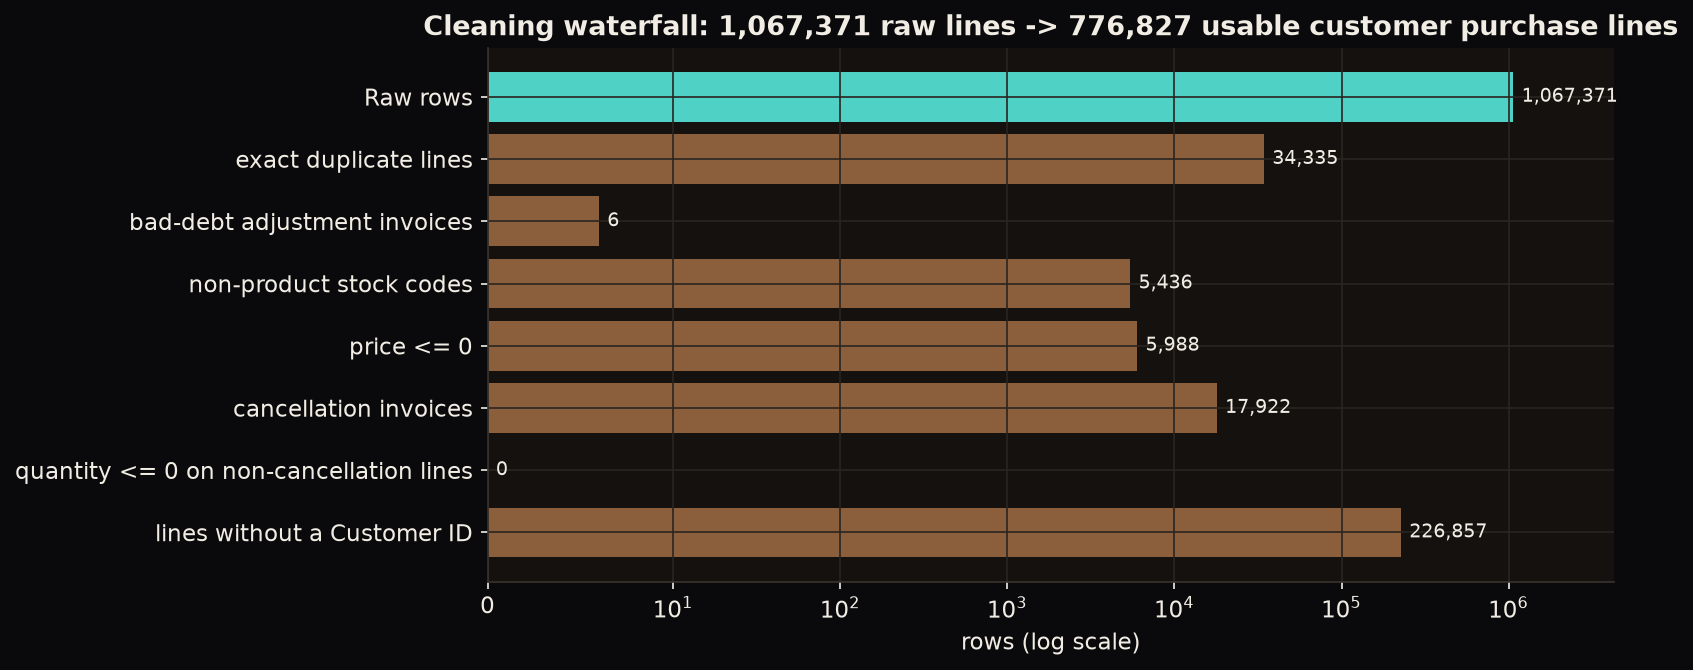

In [4]:
print(f"guest lines: {rep['guest_lines']:,} = {rep['guest_revenue_share_pct']:.1f}% of revenue (kept for totals, unusable per customer)")
print(f"clean: {rep['clean_sales_lines']:,} lines | {rep['invoices']:,} invoices | {rep['customers']:,} customers | £{rep['revenue']:,.0f}")
Image(str(C.FIGURES_DIR / "01_cleaning_waterfall.png"))

**Order values are heavy-tailed** (median £303, max £168k for one invoice). Invoice revenue is capped at its 99.9th percentile
(£14,180) for model targets so a handful of wholesale/test orders cannot dominate CLV.

In [5]:
inv = pd.read_parquet(C.PROCESSED_DIR / "invoices.parquet")
print(inv.revenue.describe(percentiles=[.5, .9, .99, .999]).round(0).to_frame("invoice revenue £").T)
per = inv.groupby("customer_id").size()
print(f"\none-order customers: {(per == 1).mean() * 100:.1f}% | median orders per customer: {per.median():.0f}")

                     count   mean     std  min    50%    90%     99%    99.9%  \
invoice revenue £  36600.0  467.0  1359.0  0.0  303.0  824.0  3528.0  14180.0   

                        max  
invoice revenue £  168470.0  

one-order customers: 27.7% | median orders per customer: 3


### Cohort retention

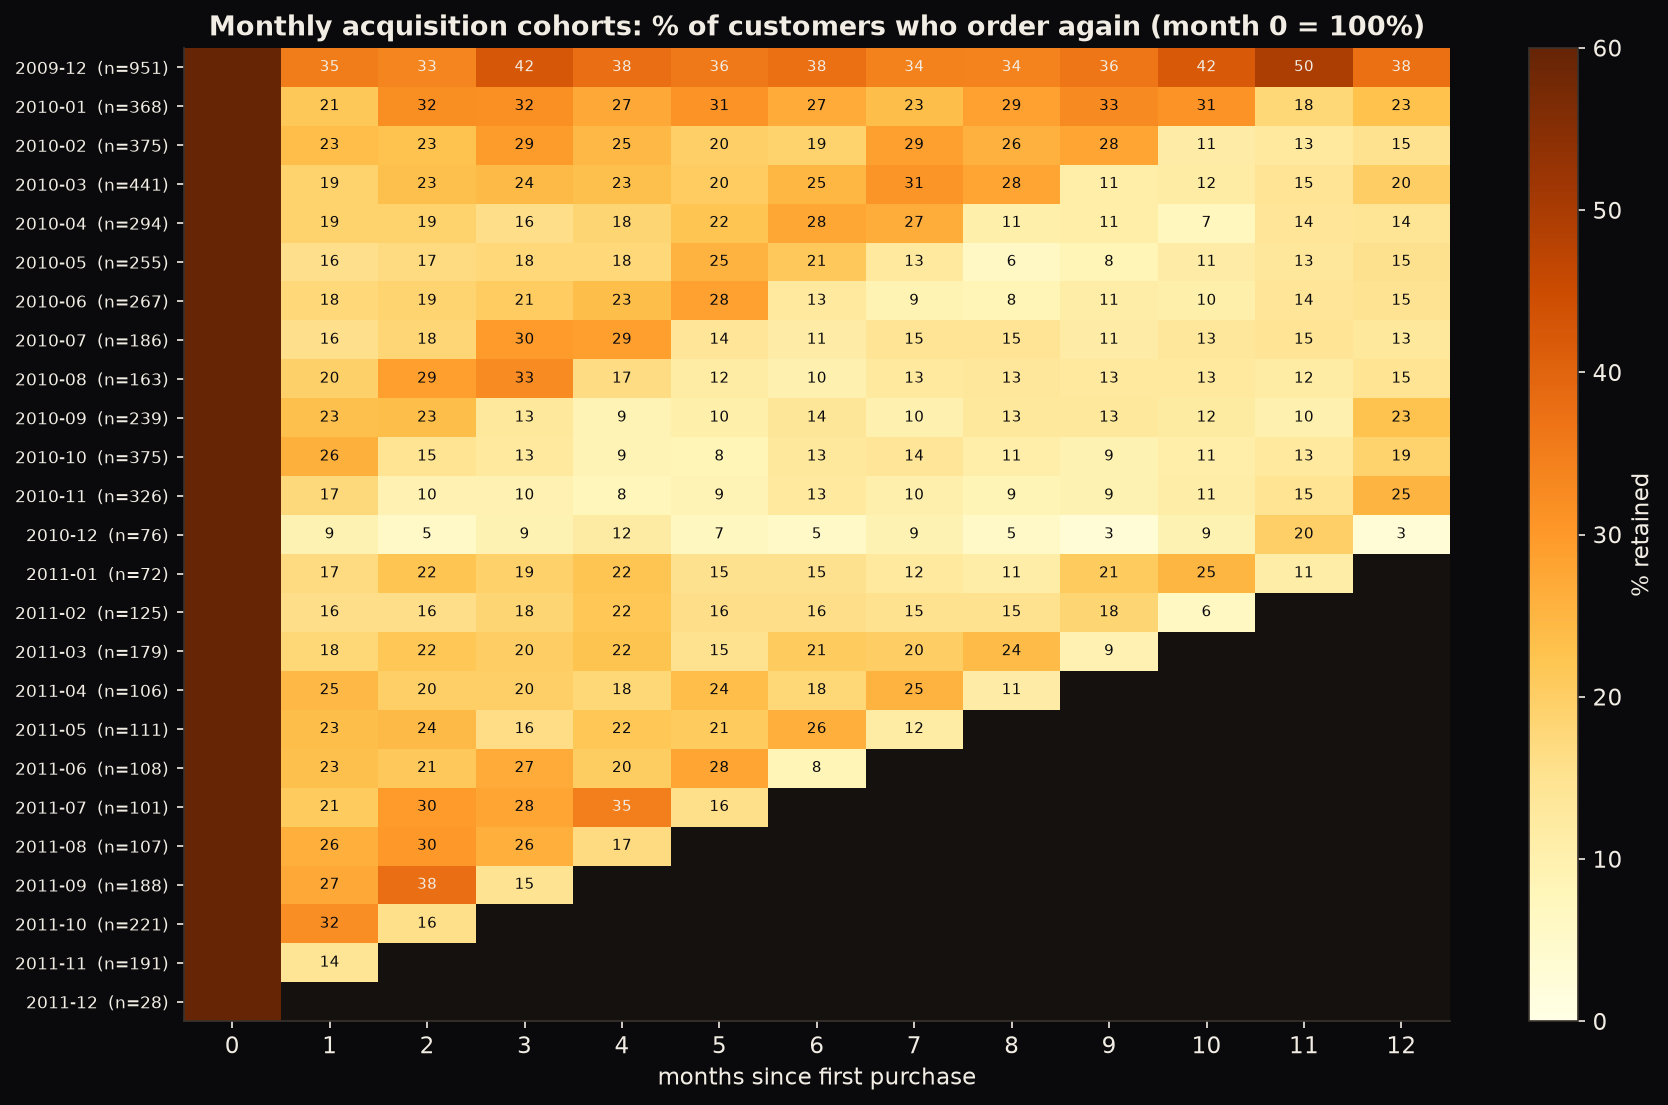

In [6]:
Image(str(C.FIGURES_DIR / "02_cohort_retention.png"))

**Insights.**
* Month-1 return rate is about 21% on average (IQR 17.5-23.5%) for cohorts after the first. The Dec-2009 cohort is a special case: it includes the retailer's *existing* customers, since the data starts that month.
* Retention drops quickly and then flattens: most customers are one-time or occasional buyers. A second order is the key event.
* Cohorts acquired Sep-Dec retain markedly worse: averaged over months 1-6, 15% (Sep), 14% (Oct), 11% (Nov), 8% (Dec) of customers are active in a given month, versus ~20% for Jan-Aug cohorts. Oct/Nov are also the largest intakes (375/326 customers vs ~240 typical) - seasonal gift buyers.

### RFM + K-Means segmentation (snapshot 2011-12-09)

 k  inertia  silhouette
 2 8568.687       0.442
 3 6349.215       0.347
 4 4939.138       0.364
 5 4119.906       0.345
 6 3567.448       0.340
 7 3191.301       0.308
 8 2899.093       0.306
 9 2661.677       0.290


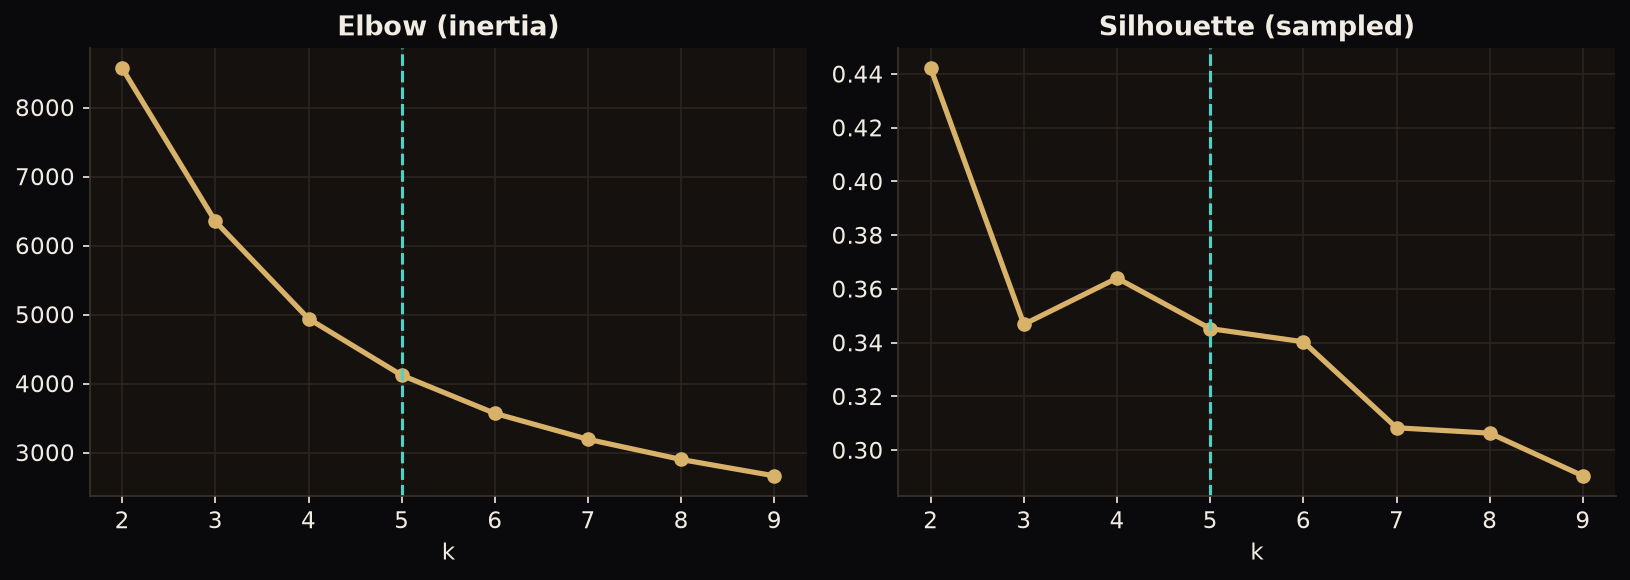

In [7]:
m = json.loads((C.ARTIFACTS_DIR / "metrics.json").read_text())
k = pd.DataFrame(m["segmentation"]["k_selection"]); print(k.round(3).to_string(index=False))
Image(str(C.FIGURES_DIR / "03_k_selection.png"))

Silhouette is highest for k=2 (a trivial active/inactive split) and is similar for k=3-5 (0.35-0.36); the elbow bends around 4-5.
**k=5** is chosen because it separates *Champions* from *Loyal* buyers (k=4 merges them), which is a distinction with very different
marketing actions.

In [8]:
seg = pd.read_parquet(C.ARTIFACTS_DIR / "segment_summary.parquet")
seg[["segment", "customers", "customer_share_pct", "revenue_share_pct", "median_recency", "median_orders",
     "median_order_value", "avg_churn_prob"]].round(1).sort_values("revenue_share_pct", ascending=False)

,segment,customers,customer_share_pct,revenue_share_pct,median_recency,median_orders,median_order_value,avg_churn_prob
1,Champions,442,7.6,53.6,7.0,24.0,390.2,0.1
3,Loyal,1263,21.6,27.5,30.0,9.0,337.0,0.2
0,At Risk,1367,23.4,11.8,254.0,4.0,313.2,0.5
4,New Customers,1118,19.1,4.5,26.0,2.0,244.0,0.4
2,Lost,1663,28.4,2.7,413.0,1.0,187.0,0.7


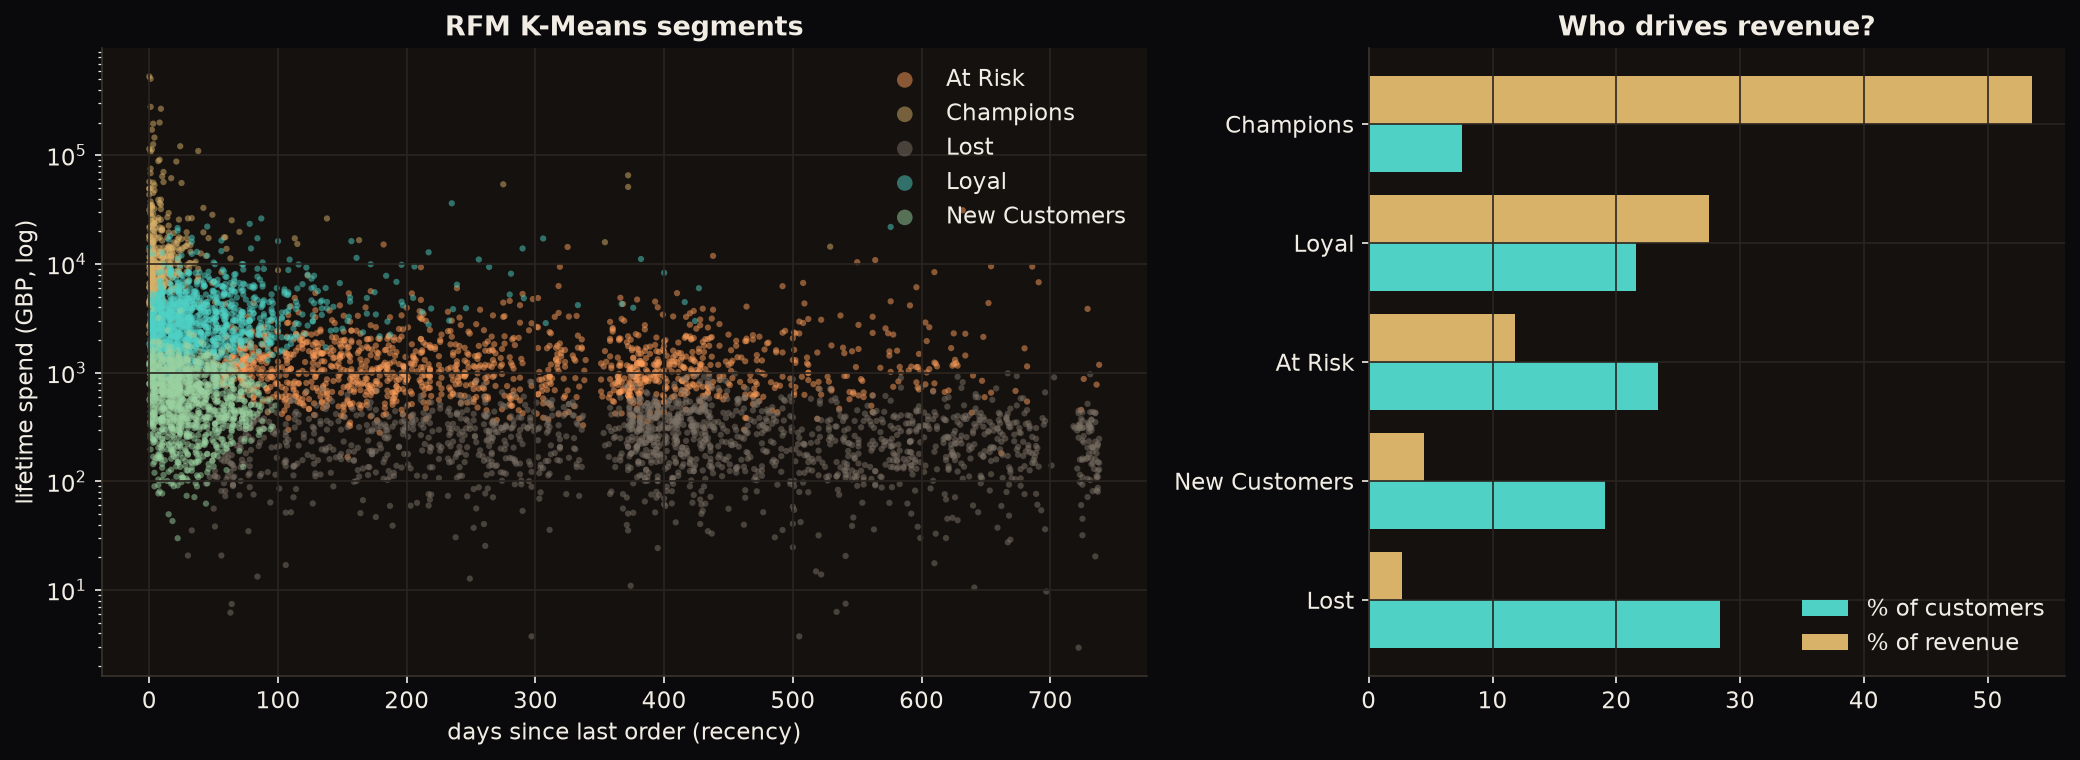

In [9]:
Image(str(C.FIGURES_DIR / "04_segments.png"))

**Insights.** 7.6% of customers (Champions) generate 54% of revenue; the 28% of customers who are *Lost* generate under 3%.
Personas are named from cluster medians with explicit thresholds (recency ≤ 60 d & ≥ 15 orders → Champions, etc.; see `segment.name_personas`),
so they are reproducible rather than eyeballed.